# Generate parameter sweeps
code from `notebooks-part2/Part1_Block2_ParameterSensitivity.ipynb`

In [7]:
import sys
import json
import re
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data' / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / 'data' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

print('Setup complete.')

Setup complete.


In [ ]:
# radii = range(15, 170, 15)

# rows_r = []
# for r in radii:
#     print(f'  running r={r} …', end=' ', flush=True)
#     outdir = OUTPUT_ROOT / f'sweep_r{r}'
#     cmd = [
#         sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
#         '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
#         '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
#         '--signal-col', SIGNAL_COL,
#         '--spatial-radius', str(r),
#         '--future-window-frames', '3',
#         '--jump-quantile', '0.9',
#         '--output-dir', str(outdir),
#     ]
#     # subprocess.run(cmd, capture_output=True)
#     sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
#     if sp is None:
#         sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
#     with open(sp) as f:
#         s = json.load(f)
# rows_r.append({
#     'r': r,
#     '|E_sp|': s['n_spatial_edges'],
#     'θ': round(s['jump_threshold'], 4),
#     'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
#     'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
#     'RR': round(s['relative_risk'], 4),
#     'RD': round(s['risk_difference'], 4),
# })
# print('done')

# df_r = pd.DataFrame(rows_r).set_index('r')

  running r=15 …   running r=30 …   running r=45 …   running r=60 …   running r=75 …   running r=90 …   running r=105 …   running r=120 …   running r=135 …   running r=150 …   running r=165 … done


# Saptial radius ($r$) sweep

## Load data from parameter sweeps

In [8]:
summary_files = sorted(OUTPUT_ROOT.glob("sweep_r*/exp_1_site_1_ERKKTR_ratio/summary.json"))

rows = []
for p in summary_files:
    with open(p) as f:
        d = json.load(f)
    m = re.search(r"sweep_r(\d+)", str(p))
    d["r"] = int(m.group(1)) if m else None
    rows.append(d)

df_sweeps = pd.DataFrame(rows).sort_values("r").set_index("r")
df_sweeps['average_n_neighbors'] = df_sweeps['n_spatial_edges'] / df_sweeps['n_nodes'] * 2
df_sweeps

,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,n_tracks,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,average_n_neighbors
r,,,,,,,,,,,,,,,,,,,
15,1,1,WT,ERKKTR_ratio,15.0,3,0.036543,356632,8168,354834,1798,258,1086,355546,0.327808,0.097430,0.230378,3.364539,0.045806
30,1,1,WT,ERKKTR_ratio,30.0,3,0.036543,356632,508839,354834,1798,258,43171,313461,0.179704,0.086898,0.092806,2.067998,2.853580
45,1,1,WT,ERKKTR_ratio,45.0,3,0.036543,356632,1304572,354834,1798,258,94198,262434,0.149653,0.079639,0.070014,1.879139,7.316068
60,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,1798,258,146620,210012,0.131455,0.074867,0.056588,1.755850,13.400390
75,1,1,WT,ERKKTR_ratio,75.0,3,0.036543,356632,3761864,354834,1798,258,196896,159736,0.119352,0.071975,0.047377,1.658247,21.096615
90,1,1,WT,ERKKTR_ratio,90.0,3,0.036543,356632,5401402,354834,1798,258,239638,116994,0.111981,0.069764,0.042217,1.605140,30.291180
105,1,1,WT,ERKKTR_ratio,105.0,3,0.036543,356632,7283073,354834,1798,258,274148,82484,0.106851,0.069153,0.037698,1.545144,40.843632
120,1,1,WT,ERKKTR_ratio,120.0,3,0.036543,356632,9409711,354834,1798,258,300523,56109,0.103323,0.070327,0.032996,1.469174,52.769864
135,1,1,WT,ERKKTR_ratio,135.0,3,0.036543,356632,11760201,354834,1798,258,319585,37047,0.101194,0.071720,0.029474,1.410961,65.951463


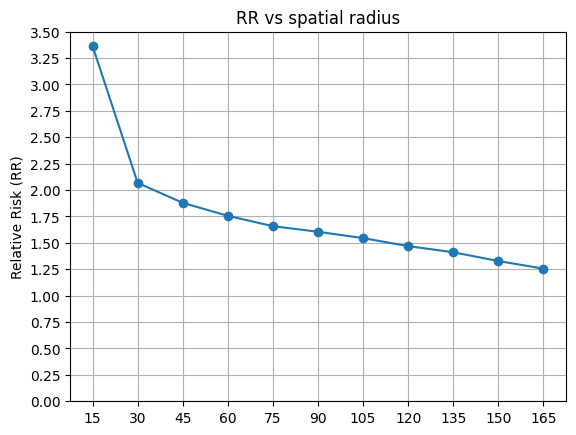

In [9]:
import matplotlib.pyplot as plt

plt.plot(df_sweeps.index, df_sweeps['relative_risk'], marker='o')
plt.grid()
plt.title("RR vs spatial radius")
plt.yticks(np.arange(0, df_sweeps['relative_risk'].max() + 0.25, 0.25))
plt.xticks(df_sweeps.index)
plt.ylabel("Relative Risk (RR)")
plt.show()

In [17]:
neighbor_table = df_sweeps[['average_n_neighbors']].round(2)
neighbor_table

,average_n_neighbors
r,
15,0.05
30,2.85
45,7.32
60,13.40
75,21.10
90,30.29
105,40.84
120,52.77
135,65.95
